Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 16)                  │         100,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,473 (412.00 KB)

 Trainable params: 105,473 (412.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6875 - loss: 0.6882 - val_accuracy: 0.5000 - val_loss: 0.7445
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5000 - loss: 0.6778 - val_accuracy: 0.5000 - val_loss: 0.7020
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5000 - loss: 0.6503 - val_accuracy: 0.2500 - val_loss: 0.7226
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9375 - loss: 0.5997 - val_accuracy: 0.5000 - val_loss: 0.7623
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8750 - loss: 0.5624 - val_accuracy: 0.5000 - val_loss: 0.7940
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8750 - loss: 0.5251 - val_accuracy: 0.2500 - val_loss: 0.7910
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9375 - loss: 0.4686 - val_accuracy: 0.2500 - val_loss: 0.8010
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.4310 - val_accuracy: 0.0000e+00 - val_loss

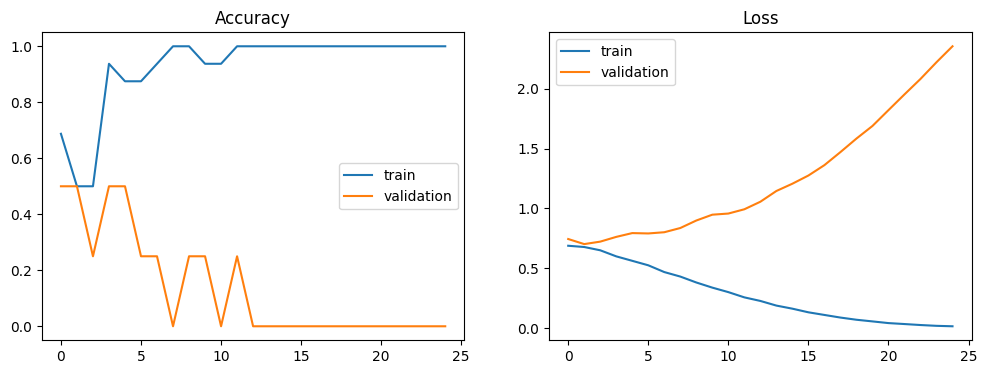

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


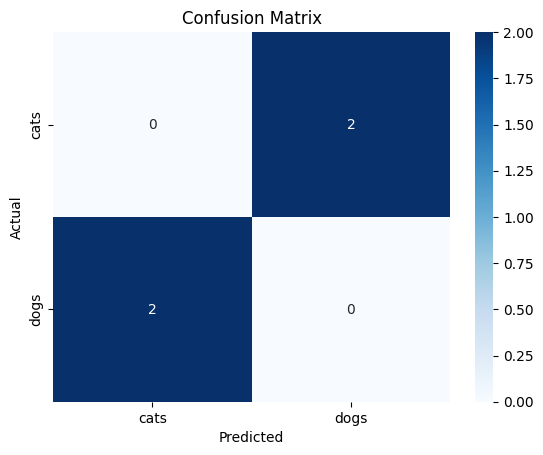

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction: Cat
Confidence: 78.44%


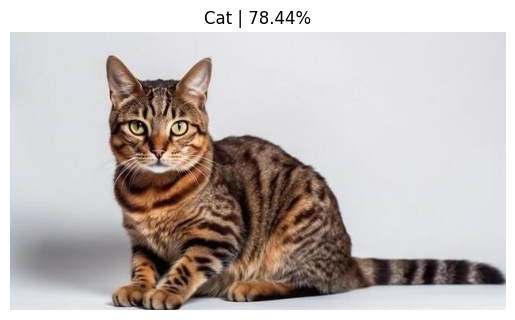

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: Cat
Confidence: 56.30%


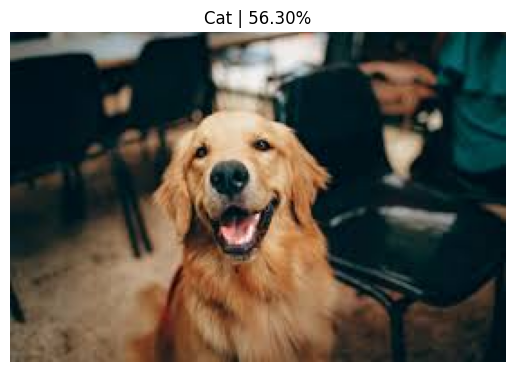

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==============================
# DATASET LOADING
# ==============================

DATADIR = "dataset"
CATEGORIES = ["cats", "dogs"]
IMG_SIZE = 64

data = []

for category in CATEGORIES:
    
    path = os.path.join(DATADIR, category)
    class_num = CATEGORIES.index(category)

    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            resized = cv2.resize(img_array,(IMG_SIZE,IMG_SIZE))
            data.append([resized,class_num])
        except:
            pass

random.shuffle(data)

X = []
y = []

for features,label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1,IMG_SIZE,IMG_SIZE,3)
y = np.array(y)

# Normalize images
X = X / 255.0


# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


# ==============================
# CNN MODEL
# ==============================

model = tf.keras.models.Sequential([
    
    tf.keras.layers.Input(shape=(IMG_SIZE,IMG_SIZE,3)),

    tf.keras.layers.Conv2D(16,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ==============================
# TRAIN MODEL
# ==============================

history = model.fit(
    X_train,
    y_train,
    epochs=25,
    validation_data=(X_test,y_test)
)


# ==============================
# MODEL EVALUATION
# ==============================

loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)


# ==============================
# SAVE MODEL
# ==============================

model.save("cat_dog_model.keras")


# ==============================
# TRAINING GRAPHS
# ==============================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label="train")
plt.plot(history.history['val_accuracy'],label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label="train")
plt.plot(history.history['val_loss'],label="validation")
plt.title("Loss")
plt.legend()

plt.show()


# ==============================
# CONFUSION MATRIX
# ==============================

predictions = model.predict(X_test)
predictions = (predictions > 0.5)

cm = confusion_matrix(y_test,predictions)

sns.heatmap(cm,annot=True,cmap="Blues",
            xticklabels=CATEGORIES,
            yticklabels=CATEGORIES)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# PREDICTION FUNCTION
# ==============================

def predict_image(image_path):

    img = cv2.imread(image_path)
    resized = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img_array = resized.reshape(-1,IMG_SIZE,IMG_SIZE,3)
    img_array = img_array/255.0

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.2f}%")

    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(f"{label} | {confidence*100:.2f}%")
    plt.axis("off")
    plt.show()


# ==============================
# TEST IMAGES
# ==============================

predict_image("test_images/test1.jpg")
predict_image("test_images/test2.jpeg")